#Building an Agentic System with LangGraph

LangGraph is a framework for building stateful AI workflows and agents as a graph.

A LangGraph system is mainly made of:

    State + Nodes + Edges

A simple agent may look like this:

   

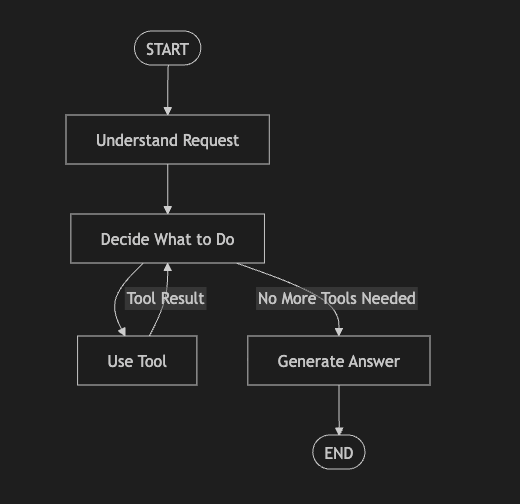

LangGraph is particularly useful when an agent needs branching, loops, tools, memory, human approval, or multiple specialized agents.

https://docs.langchain.com/oss/python/langgraph/overview



##1. What is a graph?



A graph is a collection of nodes connected by edges.

Consider a claims-processing agent:

    Receive Claim
          ↓
    Validate Claim
          ↓
    Check Policy
          ↓
    Make Decision
          ↓
    Return Result

Each box is a node.

Each arrow is an edge.

In LangGraph:

* A node performs work.

* An edge determines what happens next.

* The state carries information between nodes.

## 2. What is the state?



The state is the shared working memory of the graph.

It contains all the information that nodes need during execution.

For example:

from typing import TypedDict



In [ ]:
class ClaimState(TypedDict):
    claim_id: str
    diagnosis: str
    procedure: str
    policy_result: str
    final_decision: str

During execution, the state may look like this:

    {
        "claim_id": "CLM-1001",
        "diagnosis": "Hypertension",
        "procedure": "Heart surgery",
        "policy_result": "Procedure requires prior authorization",
        "final_decision": "Pending review"
    }

Nodes read values from the state and return updates to it. A StateGraph is specifically designed so that nodes communicate through shared state.

A good way to think about state is:

    State = The agent's shared case file

##3. What is a node?



A node is a unit of work.

In most cases, a node is simply a Python function that:

1. Receives the current state.
2. Performs an action.
3. Returns state updates.

The general structure is:



In [ ]:
def node_name(state):
    # Read information from state
    # Perform some work
    # Return updates
    return {"some_field": "new value"}

LangGraph describes a node as a function that receives the current state and returns updates to that state.

Simple node example


In [ ]:
def validate_claim(state: ClaimState):
    if not state["claim_id"]:
        return {
            "final_decision": "Rejected: Missing claim ID"
        }

    return {
        "final_decision": "Validation completed"
    }

The node does not normally need to return the complete state.

It returns only the fields it wants to update:



In [ ]:
return {
    "final_decision": "Validation completed"
}

LangGraph merges the update into the existing state.

##4. Different types of nodes



LangGraph does not enforce a fixed list of node categories. A node is generally a Python function, runnable, or subgraph.

However, in agentic-system design, nodes commonly fall into the following practical categories.



###4.1 Processing node



A processing node performs normal business logic.

Example:

In [ ]:
def calculate_claim_amount(state):
    approved_amount = state["requested_amount"] * 0.80

    return {
        "approved_amount": approved_amount
    }

Typical uses:

* Validate data
* Transform data
* Calculate values
* Apply business rules
* Format output

###4.2 LLM node



An LLM node sends information to a language model.

Example:

In [ ]:
def analyze_claim(state):
    prompt = f"""
    Analyze this claim:

    Diagnosis: {state['diagnosis']}
    Procedure: {state['procedure']}
    """

    response = model.invoke(prompt)

    return {
        "analysis": response.content
    }

Typical uses:

* Understand user requests
* Classify input
* Generate plans
* Summarize information
* Evaluate evidence
* Generate final answers

###4.3 Tool node

A tool node executes an external capability.

Examples include:

* Search a database
* Call an API
* Search the web
* Run Python code
* Retrieve documents
* Send an email
* Create a ticket

Example:

In [ ]:
def policy_search_node(state):
    policy = policy_database.search(
        diagnosis=state["diagnosis"],
        procedure=state["procedure"]
    )

    return {
        "policy_result": policy
    }

A LangGraph tool-calling agent often loops between an LLM node and a tool node until the model no longer requests a tool.

https://docs.langchain.com/oss/python/langgraph/quickstart

###4.4 Decision or router node

A router node decides where the graph should go next.

Example:

In [ ]:
def route_claim(state):
    if state["risk_score"] > 80:
        return "human_review"

    return "automatic_decision"

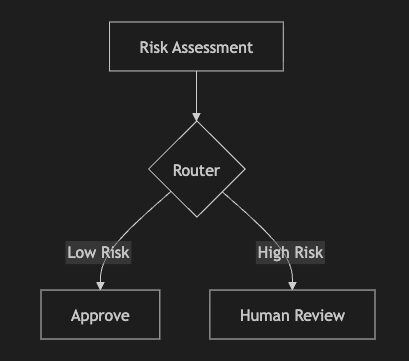

###4.5 Supervisor node

A supervisor node coordinates other nodes or agents.

For example:

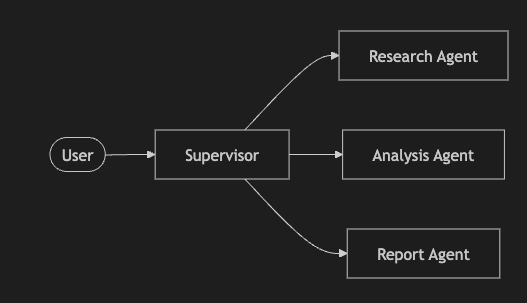

The supervisor may decide:

* Which agent should work next
* Whether the result is sufficient
* Whether another task is needed
* Whether execution should stop

*Note: Supervisor nodes are especially useful in multi-agent systems.*

Example:

In [ ]:
def supervisor(state):
    if not state.get("research_complete"):
        return "research_agent"

    if not state.get("analysis_complete"):
        return "analysis_agent"

    return "report_agent"

###4.6 Human-in-the-loop node

A human-in-the-loop node pauses execution and requests human input or approval.

Example use case:

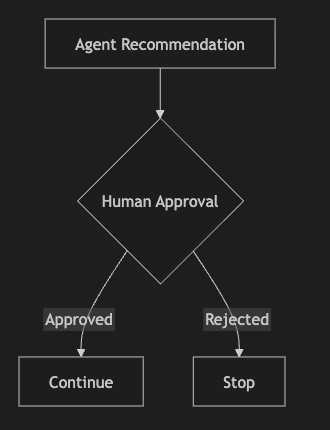

LangGraph supports interrupts that pause graph execution, save the state, and resume after external input is provided.

https://docs.langchain.com/oss/python/langgraph/interrupts

In [ ]:
from langgraph.types import interrupt

def human_review(state):
    decision = interrupt({
        "claim_id": state["claim_id"],
        "recommendation": state["recommendation"],
        "question": "Approve this claim?"
    })

    return {
        "human_decision": decision
    }

###4.7 Subgraph node

A subgraph is a complete graph used as a node inside another graph.

For example:

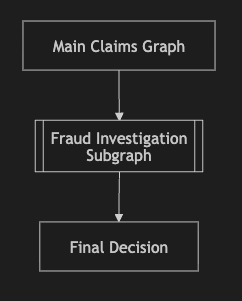

The fraud investigation subgraph might contain:

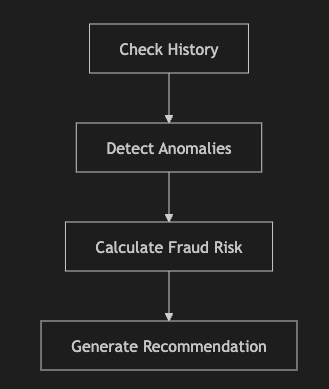

Subgraphs are useful for reusable workflows, complex systems, multi-agent systems, and separation of responsibilities between teams.

https://docs.langchain.com/oss/python/langgraph/use-subgraphs

###4.8 Start and end nodes

LangGraph provides two special graph markers:

    START
    END

**START** represents the beginning of graph execution.

**END** represents completion.

Example:

In [ ]:
graph.add_edge(START, "validate_claim")
graph.add_edge("generate_decision", END)

##5. What is an edge?

An edge defines the movement from one node to another.

It answers:

    After this node finishes, what happens next?

For example:

    Validate Claim → Check Policy

In code:

In [ ]:
graph.add_edge("validate_claim", "check_policy")

##6. Types of edges

###6.1 Normal edge

A normal edge always moves from one node to another.

    Node A → Node B

Example:

In [ ]:
graph.add_edge("validate_claim", "check_policy")

Use a normal edge when the next step is always known.

Example:

    Receive Order
          ↓
    Validate Order
          ↓
    Calculate Total
          ↓
    Generate Invoice

The official LangGraph documentation describes normal edges as direct transitions from one node to the next.

https://docs.langchain.com/oss/python/langgraph/graph-api

###Conditional edge

A conditional edge chooses the next node based on the state.

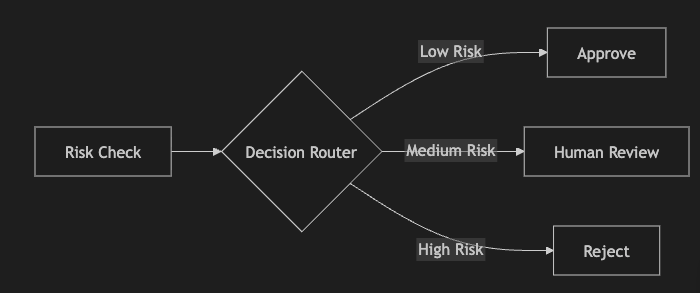

First, create a routing function:

In [ ]:
def route_by_risk(state):
    risk = state["risk_score"]

    if risk < 30:
        return "approve"

    if risk < 70:
        return "human_review"

    return "reject"

Then connect it:

In [ ]:
graph.add_conditional_edges(
    "Risk_Check",
    route_by_risk,
    {
        "approve": "Approve",
        "human_review": "Human_Review",
        "reject": "Reject"
    }
)

A conditional edge calls a routing function after a node finishes and uses its result to choose one or more destination nodes.

https://docs.langchain.com/oss/python/langgraph/graph-api

###6.3 Entry edge

An entry edge connects START to the first node.

In [ ]:
graph.add_edge(START, "understand_request")

Graphically:

    START → Understand Request

###6.4 Conditional entry edge

Sometimes the first node depends on the input.

For example:

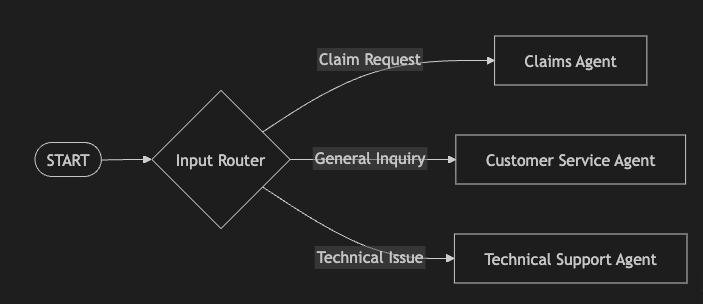

A routing function can select the first node:

In [ ]:
def choose_start_node(state):
    request_type = state["request_type"]

    if request_type == "claim":
        return "claims_agent"

    if request_type == "technical":
        return "technical_agent"

    return "customer_service_agent"

Then:

In [ ]:
graph.set_conditional_entry_point(
    choose_start_node,
    {
        "claims_agent": "claims_agent",
        "technical_agent": "technical_agent",
        "customer_service_agent": "customer_service_agent"
    }
)

###6.5 Loop or cyclic edge

An edge may return execution to an earlier node.

This creates a loop.


For example:

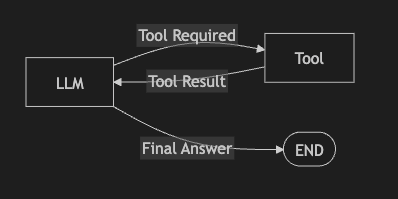

In [ ]:
graph.add_edge("tool_node", "llm_node")

The conditional edge from the LLM decides whether to call another tool or stop:

In [ ]:
def should_continue(state):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "end"

In [ ]:
graph.add_conditional_edges(
    "llm_node",
    should_continue,
    {
        "tools": "tool_node",
        "end": END
    }
)

This loop is one of the main differences between an ordinary workflow and an agentic workflow.

The agent can repeatedly reason, act, observe, and reason again:

      Reason → Act → Observe → Reason

###6.6 Parallel or fan-out edges

One node can connect to multiple nodes.

The destination nodes may run in parallel as part of the next graph execution step.

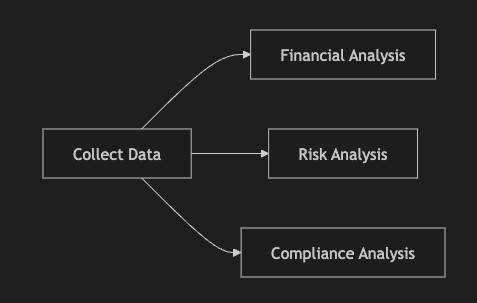

In [ ]:
graph.add_edge("collect_data", "financial_analysis")
graph.add_edge("collect_data", "risk_analysis")
graph.add_edge("collect_data", "compliance_analysis")

###6.7 Fan-in edge

Fan-in occurs when several nodes connect to one later node.

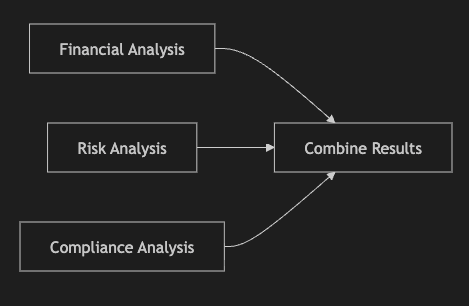

In [ ]:
graph.add_edge("financial_analysis", "combine_results")
graph.add_edge("risk_analysis", "combine_results")
graph.add_edge("compliance_analysis", "combine_results")

You may need reducers when multiple parallel nodes update the same state field.

In [ ]:
import operator
from typing import Annotated, TypedDict

class AnalysisState(TypedDict):
    results: Annotated[list[str], operator.add]

Each node may return:

    return {
        "results": ["Risk analysis completed"]
    }

The reducer combines the lists instead of replacing one result with another.

###6.8 Dynamic routing with Command

A node can update the state and select the next node in the same return value using [Command].

In [ ]:
from typing import Literal
from langgraph.types import Command

def supervisor(
    state: AgentState
) -> Command[Literal["researcher", "writer"]]:

    if not state.get("research"):
        return Command(
            update={"current_phase": "research"},
            goto="researcher"
        )

    return Command(
        update={"current_phase": "writing"},
        goto="writer"
    )

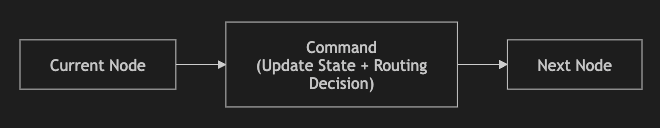

LangGraph supports this as an alternative to defining separate conditional edges.

https://docs.langchain.com/oss/python/langgraph/use-graph-api

##7. Workflow versus agent

A workflow follows mostly predefined steps.

    A → B → C → D

An agent dynamically decides what to do.

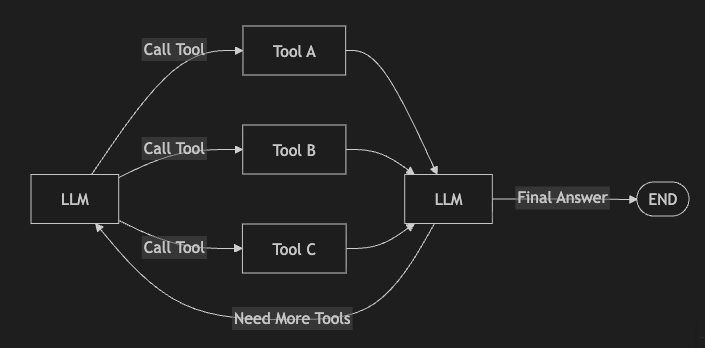

LangGraph documentation distinguishes them as follows:

* Workflow: predetermined code paths.
* Agent: dynamically determines its process and tool usage. https://docs.langchain.com/oss/python/langgraph/workflows-agents

A LangGraph application can combine both.

For example:

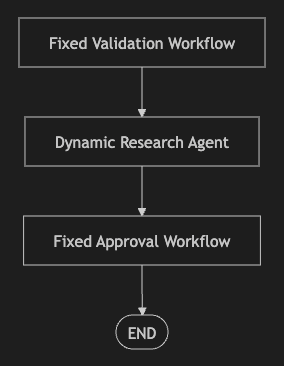

##8. Basic steps for building a LangGraph agent

The normal development process is:

    1. Define the state
    2. Create the nodes
    3. Create the graph
    4. Add the nodes
    5. Add the edges
    6. Compile the graph
    7. Invoke the graph

##9. Complete simple example

The following example builds a basic customer-support routing system.

**Step 1: Install packages**

In [ ]:
pip install -U langgraph langchain langchain-openai

**Step 2: Define the state**

In [ ]:
from typing import TypedDict

class SupportState(TypedDict):
    customer_message: str
    category: str
    response: str

**Step 3: Create nodes**

In [ ]:
def classify_request(state: SupportState):
    message = state["customer_message"].lower()

    if "refund" in message or "payment" in message:
        category = "billing"
    elif "error" in message or "not working" in message:
        category = "technical"
    else:
        category = "general"

    return {
        "category": category
    }


def billing_agent(state: SupportState):
    return {
        "response": (
            "Your request has been assigned to the billing team."
        )
    }


def technical_agent(state: SupportState):
    return {
        "response": (
            "Your request has been assigned to technical support."
        )
    }


def general_agent(state: SupportState):
    return {
        "response": (
            "Your request has been assigned to customer service."
        )
    }

**Step 4: Create the routing function**

In [ ]:
def route_request(state: SupportState):
    return state["category"]

**Step 5: Build the graph**

In [ ]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(SupportState)

builder.add_node("classify_request", classify_request)
builder.add_node("billing_agent", billing_agent)
builder.add_node("technical_agent", technical_agent)
builder.add_node("general_agent", general_agent)

**Step 6: Add edges**

In [ ]:
builder.add_edge(START, "classify_request")

builder.add_conditional_edges(
    "classify_request",
    route_request,
    {
        "billing": "billing_agent",
        "technical": "technical_agent",
        "general": "general_agent"
    }
)

builder.add_edge("billing_agent", END)
builder.add_edge("technical_agent", END)
builder.add_edge("general_agent", END)

**Step 7: Compile the graph**

In [ ]:
support_system = builder.compile()

Compilation converts the graph definition into an executable application.

**Step 8: Run it**

In [ ]:
result = support_system.invoke({
    "customer_message": "I was charged twice for my subscription",
    "category": "",
    "response": ""
})

print(result)

Expected result:

    {
        "customer_message": "I was charged twice for my subscription",
        "category": "billing",
        "response": "Your request has been assigned to the billing team."
    }

The execution path is:

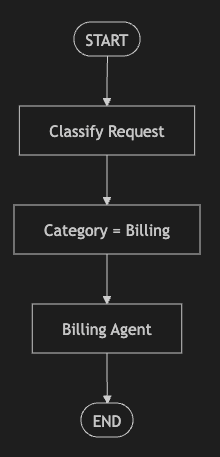

##10. Building a tool-calling agent

A more agentic design lets an LLM decide whether it needs a tool.

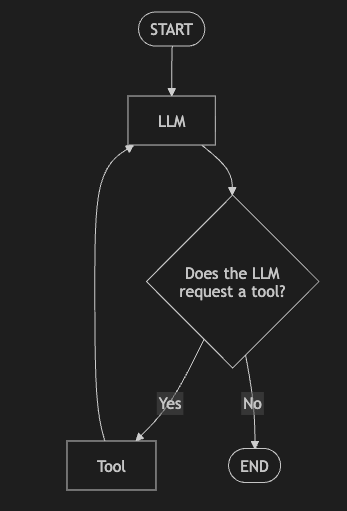

**State**


In [ ]:
from langgraph.graph import MessagesState

[MessagesState] is a predefined state structure for maintaining conversation messages.

**Nodes**

In [ ]:
def llm_node(state: MessagesState):
    response = model_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }


def tool_node(state: MessagesState):
    results = []

    last_message = state["messages"][-1]

    for tool_call in last_message.tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke(tool_call["args"])

        results.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            )
        )

    return {
        "messages": results
    }

**Routing function**

In [ ]:
from typing import Literal
from langgraph.graph import END

def should_continue(
    state: MessagesState
) -> Literal["tool_node", "__end__"]:

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tool_node"

    return END

**Graph**

In [ ]:
builder = StateGraph(MessagesState)

builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)

builder.add_edge(START, "llm_node")

builder.add_conditional_edges(
    "llm_node",
    should_continue
)

builder.add_edge("tool_node", "llm_node")

agent = builder.compile()

This is an agent because the LLM dynamically decides:

* Whether a tool is needed
* Which tool to use
* What arguments to send
* Whether another tool call is required
* When it has enough information to answer